###### 131_2_practical_extract_monthly_line_answer.ipynb

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt

In [3]:
pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Meiryo"

In [4]:
#cell2
df_defect = pd.read_csv("dataset/defect_comment_monthly.csv")
df_defect

,occ_month,site,model,defect_id,comment
0,2026-01,SUS,J69P,D-001,2026/01にKLAK-67890で1件発生。160V条件で確認。
1,2026-01,SUS,J69P,D-002,2026/01にLCM-220を確認。再発の可能性あり。
2,2026-01,WSE,310D,D-003,2026/01にCAN-330で1件発生。
3,2026-01,GSE,J69P,D-004,コメントのみ。対象品番の記載なし。
4,2026-01,MELMB,310D,D-005,KLEE-55555は継続確認中。
5,2026-02,SUS,J69P,D-006,KLAK-67890とLCM-220を確認。
6,2026-02,SUS,J69P,D-007,KLBC-12345で焼損痕あり。
7,2026-02,WSE,310D,D-008,温度85C条件でCAN-330の1件を確認。
8,2026-02,GSE,J69P,D-009,CAN-330で1件再発。12V条件で確認。
9,2026-02,MELMB,310D,D-010,現象再現せず。対象品番の記載なし。


In [5]:
#cell3
selected_df = df_defect.set_index("defect_id")["comment"].str.extractall(
    r"([A-Z]{2,}-\d{3,})",
    flags=re.IGNORECASE,
)
selected_df

0
defect_id match            
D-001     0      KLAK-67890
D-002     0         LCM-220
D-003     0         CAN-330
D-005     0      KLEE-55555
D-006     0      KLAK-67890
          1         LCM-220
D-007     0      KLBC-12345
D-008     0         CAN-330
D-009     0         CAN-330
D-011     0      KLAK-67890
D-012     0         LCM-220
D-013     0          PY-110
D-014     0         CAN-330
          1      KLAK-67890
D-016     0      KLAK-67890
D-018     0         LCM-220
          1         CAN-330
D-019     0         CAN-330
D-020     0      KLEE-55555
          1          PY-110
D-021     0      KLAK-67890
D-022     0         CAN-330
D-024     0         CAN-330
          1      KLAK-67890
D-025     0          PY-110
D-026     0      KLAK-67890
          1         LCM-220
D-028     0         LCM-220
D-029     0         CAN-330
D-030     0      KLEE-55555

In [6]:
selected_df = selected_df.rename(
    columns={
        0: "part_code",
    }
)
selected_df

part_code
defect_id match            
D-001     0      KLAK-67890
D-002     0         LCM-220
D-003     0         CAN-330
D-005     0      KLEE-55555
D-006     0      KLAK-67890
          1         LCM-220
D-007     0      KLBC-12345
D-008     0         CAN-330
D-009     0         CAN-330
D-011     0      KLAK-67890
D-012     0         LCM-220
D-013     0          PY-110
D-014     0         CAN-330
          1      KLAK-67890
D-016     0      KLAK-67890
D-018     0         LCM-220
          1         CAN-330
D-019     0         CAN-330
D-020     0      KLEE-55555
          1          PY-110
D-021     0      KLAK-67890
D-022     0         CAN-330
D-024     0         CAN-330
          1      KLAK-67890
D-025     0          PY-110
D-026     0      KLAK-67890
          1         LCM-220
D-028     0         LCM-220
D-029     0         CAN-330
D-030     0      KLEE-55555

In [7]:
df_parts = selected_df.reset_index()
df_parts

,defect_id,match,part_code
0,D-001,0,KLAK-67890
1,D-002,0,LCM-220
2,D-003,0,CAN-330
3,D-005,0,KLEE-55555
4,D-006,0,KLAK-67890
5,D-006,1,LCM-220
6,D-007,0,KLBC-12345
7,D-008,0,CAN-330
8,D-009,0,CAN-330
9,D-011,0,KLAK-67890


In [8]:
#cell6
df_extract_count = df_parts.groupby(
    "defect_id",
    as_index=False,
)["part_code"].count()

df_extract_count = df_extract_count.rename(
    columns={
        "part_code": "part_code_count",
    }
)
df_extract_count

,defect_id,part_code_count
0,D-001,1
1,D-002,1
2,D-003,1
3,D-005,1
4,D-006,2
5,D-007,1
6,D-008,1
7,D-009,1
8,D-011,1
9,D-012,1


In [9]:
df_defect_check = pd.merge(
    df_defect,
    df_extract_count,
    on="defect_id",
    how="left",
)
df_defect_check.head()

,occ_month,site,model,defect_id,comment,part_code_count
0,2026-01,SUS,J69P,D-001,2026/01にKLAK-67890で1件発生。160V条件で確認。,1.0
1,2026-01,SUS,J69P,D-002,2026/01にLCM-220を確認。再発の可能性あり。,1.0
2,2026-01,WSE,310D,D-003,2026/01にCAN-330で1件発生。,1.0
3,2026-01,GSE,J69P,D-004,コメントのみ。対象品番の記載なし。,NaN
4,2026-01,MELMB,310D,D-005,KLEE-55555は継続確認中。,1.0


In [10]:
#cell8
df_defect_check["part_code_count"] = df_defect_check["part_code_count"].fillna(0)
df_defect_check
df_defect_check["part_code_count"] = df_defect_check["part_code_count"].astype(int)
df_defect_check

,occ_month,site,model,defect_id,comment,part_code_count
0,2026-01,SUS,J69P,D-001,2026/01にKLAK-67890で1件発生。160V条件で確認。,1
1,2026-01,SUS,J69P,D-002,2026/01にLCM-220を確認。再発の可能性あり。,1
2,2026-01,WSE,310D,D-003,2026/01にCAN-330で1件発生。,1
3,2026-01,GSE,J69P,D-004,コメントのみ。対象品番の記載なし。,0
4,2026-01,MELMB,310D,D-005,KLEE-55555は継続確認中。,1
5,2026-02,SUS,J69P,D-006,KLAK-67890とLCM-220を確認。,2
6,2026-02,SUS,J69P,D-007,KLBC-12345で焼損痕あり。,1
7,2026-02,WSE,310D,D-008,温度85C条件でCAN-330の1件を確認。,1
8,2026-02,GSE,J69P,D-009,CAN-330で1件再発。12V条件で確認。,1
9,2026-02,MELMB,310D,D-010,現象再現せず。対象品番の記載なし。,0


In [11]:
#cell9
df_defect_check["extract_result"] = "OK"
df_defect_check.head(3)

df_defect_check.loc[
    df_defect_check["part_code_count"] == 0,
    "extract_result",
] = "要確認"

df_defect_check.head()

,occ_month,site,model,defect_id,comment,part_code_count,extract_result
0,2026-01,SUS,J69P,D-001,2026/01にKLAK-67890で1件発生。160V条件で確認。,1,OK
1,2026-01,SUS,J69P,D-002,2026/01にLCM-220を確認。再発の可能性あり。,1,OK
2,2026-01,WSE,310D,D-003,2026/01にCAN-330で1件発生。,1,OK
3,2026-01,GSE,J69P,D-004,コメントのみ。対象品番の記載なし。,0,要確認
4,2026-01,MELMB,310D,D-005,KLEE-55555は継続確認中。,1,OK


In [12]:
#cell 10
df_month_check_summary = df_defect_check.groupby(
    [
        "occ_month",
        "extract_result",
    ],
    as_index=False,
)["defect_id"].count()
df_month_check_summary

df_month_check_summary = df_month_check_summary.rename(
    columns={
        "defect_id": "count",
    }
)
df_month_check_summary

,occ_month,extract_result,count
0,2026-01,OK,4
1,2026-01,要確認,1
2,2026-02,OK,4
3,2026-02,要確認,1
4,2026-03,OK,4
5,2026-03,要確認,1
6,2026-04,OK,4
7,2026-04,要確認,1
8,2026-05,OK,4
9,2026-05,要確認,1


In [13]:
df_total_count = df_defect_check.groupby(
    "occ_month",
    as_index=False,
)["defect_id"].count()
#df_total_count

df_total_count = df_total_count.rename(
    columns={
        "defect_id": "total_count",
    }
)

df_total_count

,occ_month,total_count
0,2026-01,5
1,2026-02,5
2,2026-03,5
3,2026-04,5
4,2026-05,5
5,2026-06,5


In [14]:
#cell 12 
df_ok_count = df_defect_check[
    df_defect_check["extract_result"] == "OK"
].groupby(
    "occ_month",
    as_index=False,
)["defect_id"].count()

df_ok_count = df_ok_count.rename(
    columns={
        "defect_id": "ok_count",
    }
)
df_ok_count

,occ_month,ok_count
0,2026-01,4
1,2026-02,4
2,2026-03,4
3,2026-04,4
4,2026-05,4
5,2026-06,4


In [15]:
df_month_ok_rate = pd.merge(
    df_total_count,
    df_ok_count,
    on="occ_month",
    how="left",
)

df_month_ok_rate["ok_count"] = df_month_ok_rate["ok_count"].fillna(0)

df_month_ok_rate["ok_count"] = df_month_ok_rate["ok_count"].astype(int)

df_month_ok_rate["ok_rate"] = (
    df_month_ok_rate["ok_count"]
    / df_month_ok_rate["total_count"]
    * 100
)

df_month_ok_rate["ok_rate"] = df_month_ok_rate["ok_rate"].round(1)

df_month_ok_rate = df_month_ok_rate.sort_values(
    "occ_month",
).reset_index(drop=True)

df_month_ok_rate

,occ_month,total_count,ok_count,ok_rate
0,2026-01,5,4,80.0
1,2026-02,5,4,80.0
2,2026-03,5,4,80.0
3,2026-04,5,4,80.0
4,2026-05,5,4,80.0
5,2026-06,5,4,80.0


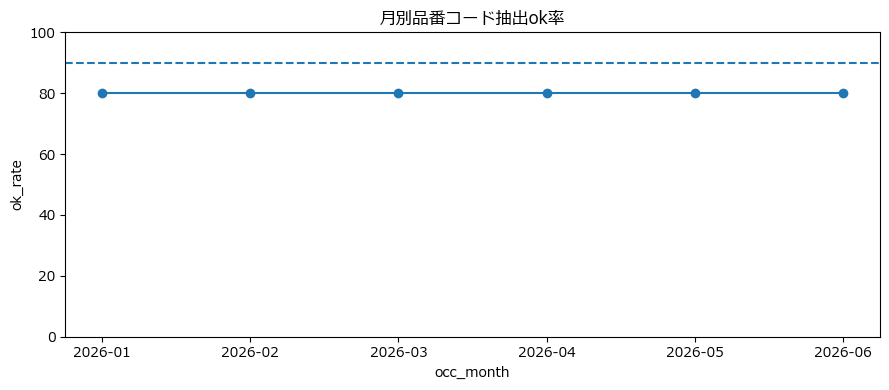

In [23]:
#cell14
plt.figure(figsize=(9, 4))

plt.plot(
    df_month_ok_rate["occ_month"],
    df_month_ok_rate["ok_rate"],
    marker="o",
)

plt.axhline(
    y=90,
    linestyle="--",
)

plt.title("月別品番コード抽出ok率")
plt.xlabel("occ_month")
plt.ylabel("ok_rate")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()